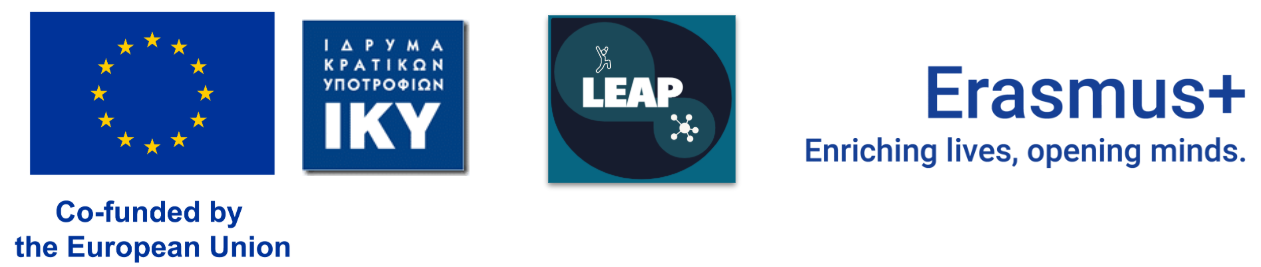

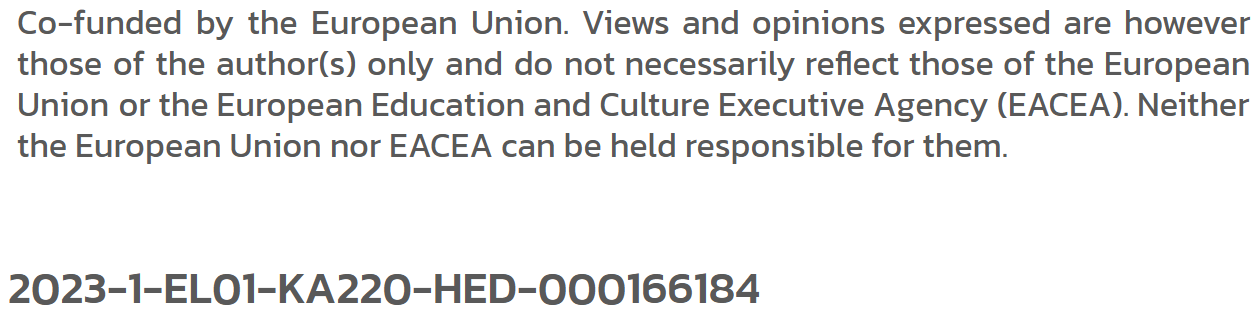

# Final Project, Option 3: How much structure can you find without the labels?

An agricultural co-op receives unlabelled deliveries of mixed wheat grain and wants to know how many distinct varieties are present, and how cleanly they separate, before committing to any sorting process. In this project you recover that structure using clustering alone.

In this project you take a data set with a known grouping, hide that grouping from yourself, and see how much of it you can recover using clustering alone. The labels are kept aside until the very end, where they serve only as an answer key.

**Central question:** how much of the real class structure can you recover without ever using the labels?

The data set is Seeds: 210 wheat kernels described by seven geometric measurements such as area, perimeter, and kernel length. You are given the measurements to work with, and the variety labels are set aside for the final check.

This project draws on Module 4. There we scaled features, reduced them with PCA, clustered with K-Means, chose the number of clusters using the elbow and silhouette methods, and validated the result against a known label with a cross-tabulation. Here you carry out that whole process yourself and judge how faithfully the clusters match the real varieties.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the scaling. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order, and resist looking at the varieties until Part D.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-66wn70i1 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Loading the data

We download the Seeds data set. The seven measurements go into `X`, and the true varieties go into `y_true`. We put the varieties aside now and do not touch them until Part D, so that the clustering is done with no knowledge of the answer.

In [2]:
# Seeds dataset embedded in the notebook so no extra .txt file is needed.
from io import StringIO

feature_names = ["area", "perimeter", "compactness", "kernel_length",
                 "kernel_width", "asymmetry", "groove_length"]

seeds_text = r"""15.26 14.84 .871 5.763 3.312 2.221 5.22 1
14.88 14.57 .8811 5.554 3.333 1.018 4.956 1
14.29 14.09 .905 5.291 3.337 2.699 4.825 1
13.84 13.94 .8955 5.324 3.379 2.259 4.805 1
16.14 14.99 .9034 5.658 3.562 1.355 5.175 1
14.38 14.21 .8951 5.386 3.312 2.462 4.956 1
14.69 14.49 .8799 5.563 3.259 3.586 5.219 1
14.11 14.10 .8911 5.420 3.302 2.700 5.000 1
16.63 15.46 .8747 6.053 3.465 2.040 5.877 1
16.44 15.25 .8880 5.884 3.505 1.969 5.533 1
15.26 14.85 .8696 5.714 3.242 4.543 5.314 1
14.03 14.16 .8796 5.438 3.201 1.717 5.001 1
13.89 14.02 .8880 5.439 3.199 3.986 4.738 1
13.78 14.06 .8759 5.479 3.156 3.136 4.872 1
13.74 14.05 .8744 5.482 3.114 2.932 4.825 1
14.59 14.28 .8993 5.351 3.333 4.185 4.781 1
13.99 13.83 .9183 5.119 3.383 5.234 4.781 1
15.69 14.75 .9058 5.527 3.514 1.599 5.046 1
14.70 14.21 .9153 5.205 3.466 1.767 4.649 1
12.72 13.57 .8686 5.226 3.049 4.102 4.914 1
14.16 14.40 .8584 5.658 3.129 3.072 5.176 1
14.11 14.26 .8722 5.520 3.168 2.688 5.219 1
15.88 14.90 .8988 5.618 3.507 .7651 5.091 1
12.08 13.23 .8664 5.099 2.936 1.415 4.961 1
15.01 14.76 .8657 5.789 3.245 1.791 5.001 1
16.19 15.16 .8849 5.833 3.421 .9030 5.307 1
13.02 13.76 .8641 5.395 3.026 3.373 4.825 1
12.74 13.67 .8564 5.395 2.956 2.504 4.869 1
14.11 14.18 .8820 5.541 3.221 2.754 5.038 1
13.45 14.02 .8604 5.516 3.065 3.531 5.097 1
13.16 13.82 .8662 5.454 2.975 .8551 5.056 1
15.49 14.94 .8724 5.757 3.371 3.412 5.228 1
14.09 14.41 .8529 5.717 3.186 3.920 5.299 1
13.94 14.17 .8728 5.585 3.150 2.124 5.012 1
15.05 14.68 .8779 5.712 3.328 2.129 5.360 1
16.12 15.00 .9000 5.709 3.485 2.270 5.443 1
16.20 15.27 .8734 5.826 3.464 2.823 5.527 1
17.08 15.38 .9079 5.832 3.683 2.956 5.484 1
14.80 14.52 .8823 5.656 3.288 3.112 5.309 1
14.28 14.17 .8944 5.397 3.298 6.685 5.001 1
13.54 13.85 .8871 5.348 3.156 2.587 5.178 1
13.50 13.85 .8852 5.351 3.158 2.249 5.176 1
13.16 13.55 .9009 5.138 3.201 2.461 4.783 1
15.50 14.86 .8820 5.877 3.396 4.711 5.528 1
15.11 14.54 .8986 5.579 3.462 3.128 5.180 1
13.80 14.04 .8794 5.376 3.155 1.560 4.961 1
15.36 14.76 .8861 5.701 3.393 1.367 5.132 1
14.99 14.56 .8883 5.570 3.377 2.958 5.175 1
14.79 14.52 .8819 5.545 3.291 2.704 5.111 1
14.86 14.67 .8676 5.678 3.258 2.129 5.351 1
14.43 14.40 .8751 5.585 3.272 3.975 5.144 1
15.78 14.91 .8923 5.674 3.434 5.593 5.136 1
14.49 14.61 .8538 5.715 3.113 4.116 5.396 1
14.33 14.28 .8831 5.504 3.199 3.328 5.224 1
14.52 14.60 .8557 5.741 3.113 1.481 5.487 1
15.03 14.77 .8658 5.702 3.212 1.933 5.439 1
14.46 14.35 .8818 5.388 3.377 2.802 5.044 1
14.92 14.43 .9006 5.384 3.412 1.142 5.088 1
15.38 14.77 .8857 5.662 3.419 1.999 5.222 1
12.11 13.47 .8392 5.159 3.032 1.502 4.519 1
11.42 12.86 .8683 5.008 2.850 2.700 4.607 1
11.23 12.63 .8840 4.902 2.879 2.269 4.703 1
12.36 13.19 .8923 5.076 3.042 3.220 4.605 1
13.22 13.84 .8680 5.395 3.070 4.157 5.088 1
12.78 13.57 .8716 5.262 3.026 1.176 4.782 1
12.88 13.50 .8879 5.139 3.119 2.352 4.607 1
14.34 14.37 .8726 5.630 3.190 1.313 5.150 1
14.01 14.29 .8625 5.609 3.158 2.217 5.132 1
14.37 14.39 .8726 5.569 3.153 1.464 5.300 1
12.73 13.75 .8458 5.412 2.882 3.533 5.067 1
17.63 15.98 .8673 6.191 3.561 4.076 6.060 2
16.84 15.67 .8623 5.998 3.484 4.675 5.877 2
17.26 15.73 .8763 5.978 3.594 4.539 5.791 2
19.11 16.26 .9081 6.154 3.930 2.936 6.079 2
16.82 15.51 .8786 6.017 3.486 4.004 5.841 2
16.77 15.62 .8638 5.927 3.438 4.920 5.795 2
17.32 15.91 .8599 6.064 3.403 3.824 5.922 2
20.71 17.23 .8763 6.579 3.814 4.451 6.451 2
18.94 16.49 .8750 6.445 3.639 5.064 6.362 2
17.12 15.55 .8892 5.850 3.566 2.858 5.746 2
16.53 15.34 .8823 5.875 3.467 5.532 5.880 2
18.72 16.19 .8977 6.006 3.857 5.324 5.879 2
20.20 16.89 .8894 6.285 3.864 5.173 6.187 2
19.57 16.74 .8779 6.384 3.772 1.472 6.273 2
19.51 16.71 .8780 6.366 3.801 2.962 6.185 2
18.27 16.09 .8870 6.173 3.651 2.443 6.197 2
18.88 16.26 .8969 6.084 3.764 1.649 6.109 2
18.98 16.66 .8590 6.549 3.670 3.691 6.498 2
21.18 17.21 .8989 6.573 4.033 5.780 6.231 2
20.88 17.05 .9031 6.450 4.032 5.016 6.321 2
20.10 16.99 .8746 6.581 3.785 1.955 6.449 2
18.76 16.20 .8984 6.172 3.796 3.120 6.053 2
18.81 16.29 .8906 6.272 3.693 3.237 6.053 2
18.59 16.05 .9066 6.037 3.860 6.001 5.877 2
18.36 16.52 .8452 6.666 3.485 4.933 6.448 2
16.87 15.65 .8648 6.139 3.463 3.696 5.967 2
19.31 16.59 .8815 6.341 3.810 3.477 6.238 2
18.98 16.57 .8687 6.449 3.552 2.144 6.453 2
18.17 16.26 .8637 6.271 3.512 2.853 6.273 2
18.72 16.34 .8810 6.219 3.684 2.188 6.097 2
16.41 15.25 .8866 5.718 3.525 4.217 5.618 2
17.99 15.86 .8992 5.890 3.694 2.068 5.837 2
19.46 16.50 .8985 6.113 3.892 4.308 6.009 2
19.18 16.63 .8717 6.369 3.681 3.357 6.229 2
18.95 16.42 .8829 6.248 3.755 3.368 6.148 2
18.83 16.29 .8917 6.037 3.786 2.553 5.879 2
18.85 16.17 .9056 6.152 3.806 2.843 6.200 2
17.63 15.86 .8800 6.033 3.573 3.747 5.929 2
19.94 16.92 .8752 6.675 3.763 3.252 6.550 2
18.55 16.22 .8865 6.153 3.674 1.738 5.894 2
18.45 16.12 .8921 6.107 3.769 2.235 5.794 2
19.38 16.72 .8716 6.303 3.791 3.678 5.965 2
19.13 16.31 .9035 6.183 3.902 2.109 5.924 2
19.14 16.61 .8722 6.259 3.737 6.682 6.053 2
20.97 17.25 .8859 6.563 3.991 4.677 6.316 2
19.06 16.45 .8854 6.416 3.719 2.248 6.163 2
18.96 16.20 .9077 6.051 3.897 4.334 5.750 2
19.15 16.45 .8890 6.245 3.815 3.084 6.185 2
18.89 16.23 .9008 6.227 3.769 3.639 5.966 2
20.03 16.90 .8811 6.493 3.857 3.063 6.320 2
20.24 16.91 .8897 6.315 3.962 5.901 6.188 2
18.14 16.12 .8772 6.059 3.563 3.619 6.011 2
16.17 15.38 .8588 5.762 3.387 4.286 5.703 2
18.43 15.97 .9077 5.980 3.771 2.984 5.905 2
15.99 14.89 .9064 5.363 3.582 3.336 5.144 2
18.75 16.18 .8999 6.111 3.869 4.188 5.992 2
18.65 16.41 .8698 6.285 3.594 4.391 6.102 2
17.98 15.85 .8993 5.979 3.687 2.257 5.919 2
20.16 17.03 .8735 6.513 3.773 1.910 6.185 2
17.55 15.66 .8991 5.791 3.690 5.366 5.661 2
18.30 15.89 .9108 5.979 3.755 2.837 5.962 2
18.94 16.32 .8942 6.144 3.825 2.908 5.949 2
15.38 14.90 .8706 5.884 3.268 4.462 5.795 2
16.16 15.33 .8644 5.845 3.395 4.266 5.795 2
15.56 14.89 .8823 5.776 3.408 4.972 5.847 2
15.38 14.66 .8990 5.477 3.465 3.600 5.439 2
17.36 15.76 .8785 6.145 3.574 3.526 5.971 2
15.57 15.15 .8527 5.920 3.231 2.640 5.879 2
15.60 15.11 .8580 5.832 3.286 2.725 5.752 2
16.23 15.18 .8850 5.872 3.472 3.769 5.922 2
13.07 13.92 .8480 5.472 2.994 5.304 5.395 3
13.32 13.94 .8613 5.541 3.073 7.035 5.440 3
13.34 13.95 .8620 5.389 3.074 5.995 5.307 3
12.22 13.32 .8652 5.224 2.967 5.469 5.221 3
11.82 13.40 .8274 5.314 2.777 4.471 5.178 3
11.21 13.13 .8167 5.279 2.687 6.169 5.275 3
11.43 13.13 .8335 5.176 2.719 2.221 5.132 3
12.49 13.46 .8658 5.267 2.967 4.421 5.002 3
12.70 13.71 .8491 5.386 2.911 3.260 5.316 3
10.79 12.93 .8107 5.317 2.648 5.462 5.194 3
11.83 13.23 .8496 5.263 2.840 5.195 5.307 3
12.01 13.52 .8249 5.405 2.776 6.992 5.270 3
12.26 13.60 .8333 5.408 2.833 4.756 5.360 3
11.18 13.04 .8266 5.220 2.693 3.332 5.001 3
11.36 13.05 .8382 5.175 2.755 4.048 5.263 3
11.19 13.05 .8253 5.250 2.675 5.813 5.219 3
11.34 12.87 .8596 5.053 2.849 3.347 5.003 3
12.13 13.73 .8081 5.394 2.745 4.825 5.220 3
11.75 13.52 .8082 5.444 2.678 4.378 5.310 3
11.49 13.22 .8263 5.304 2.695 5.388 5.310 3
12.54 13.67 .8425 5.451 2.879 3.082 5.491 3
12.02 13.33 .8503 5.350 2.810 4.271 5.308 3
12.05 13.41 .8416 5.267 2.847 4.988 5.046 3
12.55 13.57 .8558 5.333 2.968 4.419 5.176 3
11.14 12.79 .8558 5.011 2.794 6.388 5.049 3
12.10 13.15 .8793 5.105 2.941 2.201 5.056 3
12.44 13.59 .8462 5.319 2.897 4.924 5.270 3
12.15 13.45 .8443 5.417 2.837 3.638 5.338 3
11.35 13.12 .8291 5.176 2.668 4.337 5.132 3
11.24 13.00 .8359 5.090 2.715 3.521 5.088 3
11.02 13.00 .8189 5.325 2.701 6.735 5.163 3
11.55 13.10 .8455 5.167 2.845 6.715 4.956 3
11.27 12.97 .8419 5.088 2.763 4.309 5.000 3
11.40 13.08 .8375 5.136 2.763 5.588 5.089 3
10.83 12.96 .8099 5.278 2.641 5.182 5.185 3
10.80 12.57 .8590 4.981 2.821 4.773 5.063 3
11.26 13.01 .8355 5.186 2.710 5.335 5.092 3
10.74 12.73 .8329 5.145 2.642 4.702 4.963 3
11.48 13.05 .8473 5.180 2.758 5.876 5.002 3
12.21 13.47 .8453 5.357 2.893 1.661 5.178 3
11.41 12.95 .8560 5.090 2.775 4.957 4.825 3
12.46 13.41 .8706 5.236 3.017 4.987 5.147 3
12.19 13.36 .8579 5.240 2.909 4.857 5.158 3
11.65 13.07 .8575 5.108 2.850 5.209 5.135 3
12.89 13.77 .8541 5.495 3.026 6.185 5.316 3
11.56 13.31 .8198 5.363 2.683 4.062 5.182 3
11.81 13.45 .8198 5.413 2.716 4.898 5.352 3
10.91 12.80 .8372 5.088 2.675 4.179 4.956 3
11.23 12.82 .8594 5.089 2.821 7.524 4.957 3
10.59 12.41 .8648 4.899 2.787 4.975 4.794 3
10.93 12.80 .8390 5.046 2.717 5.398 5.045 3
11.27 12.86 .8563 5.091 2.804 3.985 5.001 3
11.87 13.02 .8795 5.132 2.953 3.597 5.132 3
10.82 12.83 .8256 5.180 2.630 4.853 5.089 3
12.11 13.27 .8639 5.236 2.975 4.132 5.012 3
12.80 13.47 .8860 5.160 3.126 4.873 4.914 3
12.79 13.53 .8786 5.224 3.054 5.483 4.958 3
13.37 13.78 .8849 5.320 3.128 4.670 5.091 3
12.62 13.67 .8481 5.410 2.911 3.306 5.231 3
12.76 13.38 .8964 5.073 3.155 2.828 4.830 3
12.38 13.44 .8609 5.219 2.989 5.472 5.045 3
12.67 13.32 .8977 4.984 3.135 2.300 4.745 3
11.18 12.72 .8680 5.009 2.810 4.051 4.828 3
12.70 13.41 .8874 5.183 3.091 8.456 5.000 3
12.37 13.47 .8567 5.204 2.960 3.919 5.001 3
12.19 13.20 .8783 5.137 2.981 3.631 4.870 3
11.23 12.88 .8511 5.140 2.795 4.325 5.003 3
13.20 13.66 .8883 5.236 3.232 8.315 5.056 3
11.84 13.21 .8521 5.175 2.836 3.598 5.044 3
12.30 13.34 .8684 5.243 2.974 5.637 5.063 3"""

data = pd.read_csv(StringIO(seeds_text), sep=r"\s+", header=None)
X = data.iloc[:, :7].copy()
X.columns = feature_names

# Keep the true varieties aside until Part D.
y_true = data.iloc[:, 7].to_numpy().astype(int)

print("Rows and features:", X.shape)
X.head()


Rows and features: (210, 7)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Scaling the features

Clustering relies on distances between points, so a feature measured on a larger scale would count for more than the others. We put every feature on the same footing with `StandardScaler`, as in Module 4.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix:", X_scaled.shape)

Scaled feature matrix: (210, 7)


## Part B. Explore, without labels

From here on, the cells are yours to complete.

First, look at the shape of the data. Seven measurements are too many to plot at once, so reduce them to two with PCA and draw a scatter. This is the same reduction you used in Module 4.

Explained variance ratio: [0.71874303 0.17108184]
Total explained variance: 0.89


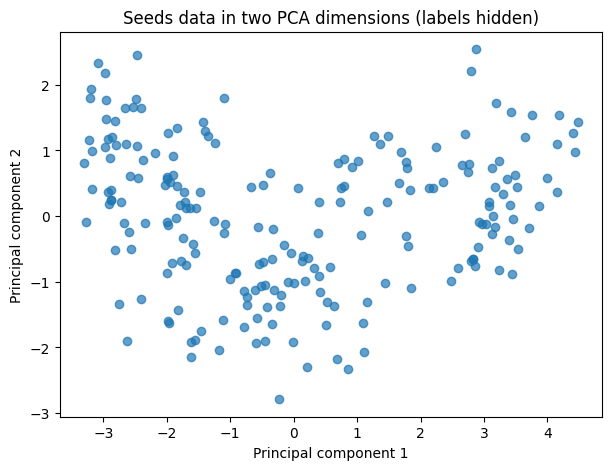

In [4]:
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Seeds data in two PCA dimensions (labels hidden)")
plt.show()


### What do you see?

From the PCA plot, I can see about three main groups. One group looks quite separate, while the other two overlap more. This suggests that there is some real structure in the data, but the groups are not perfectly separated.


## Part C. Cluster and choose the number of groups

Now decide how many clusters the data supports, using the two methods from Module 4. The elbow method looks at inertia, the total spread of points around their cluster centres, and finds where adding another cluster stops helping much. The silhouette score measures how well separated the clusters are, where higher is better.

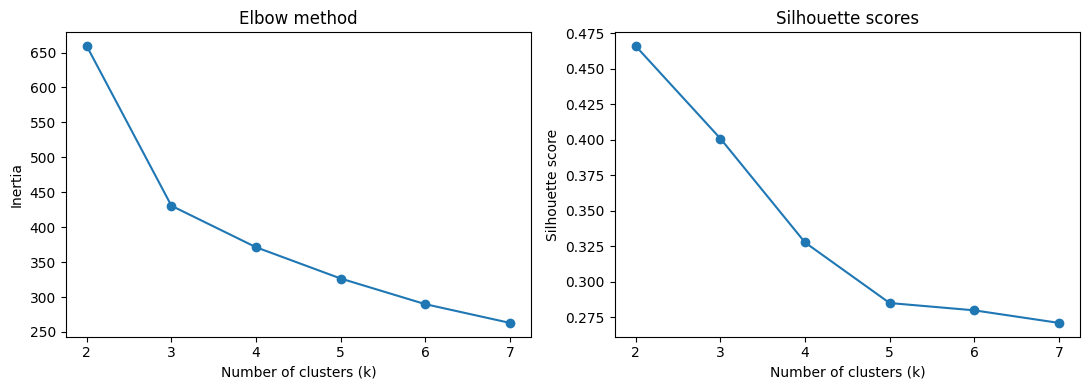

k=2: inertia=659.17, silhouette=0.466
k=3: inertia=430.66, silhouette=0.401
k=4: inertia=371.30, silhouette=0.328
k=5: inertia=326.51, silhouette=0.285
k=6: inertia=289.80, silhouette=0.280
k=7: inertia=262.97, silhouette=0.271


In [5]:
ks = range(2, 8)
inertias = []
silhouettes = []

for k_test in ks:
    km_test = KMeans(n_clusters=k_test, n_init=10, random_state=42)
    km_test.fit(X_scaled)
    inertias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km_test.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")
axes[1].plot(list(ks), silhouettes, marker="o")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette scores")
plt.tight_layout()
plt.show()

for k_test, inertia, sil in zip(ks, inertias, silhouettes):
    print(f"k={k_test}: inertia={inertia:.2f}, silhouette={sil:.3f}")


### How many clusters?

I chose **k = 3**. The silhouette score is actually highest for k = 2, but the elbow plot still improves a lot up to k = 3 and then the changes become smaller. Because of this, I think three clusters are a reasonable choice when I look at both methods together.


### Fit K-Means

Fit K-Means at the number of clusters you decided on, and keep the cluster assignment for each kernel.

In [6]:
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)
print("Cluster sizes:", np.bincount(labels))


Cluster sizes: [72 67 71]


## Part D. Judge against the labels

We now bring in the true varieties for the first time, only as an external check. The clustering itself is finished; nothing below changes it. We simply ask how well the groups you found line up with the real varieties, exactly as we validated the clusters in Module 4.

In [7]:
print("Varieties present:", np.unique(y_true))
ct = pd.crosstab(pd.Series(labels, name="Cluster"),
                 pd.Series(y_true, name="True variety"))
print(ct)


Varieties present: [1 2 3]
True variety   1   2   3
Cluster                 
0              6   0  66
1              2  65   0
2             62   5   4


### Measuring the agreement

Turn the table into a single number with a purity score. For each cluster, take the count of its most common variety; add those counts across all clusters; then divide by the total number of kernels. A value near 1 means each cluster is almost entirely one variety.

Purity tends to increase when more clusters are created, so interpret it together with your chosen value of `k` and the cross-tabulation rather than using it on its own.

In [8]:
purity = ct.max(axis=1).sum() / ct.values.sum()
print(f"Purity score: {purity:.3f}")


Purity score: 0.919


### Back to the picture

Connect the numbers to the shape you saw earlier. Redraw the PCA scatter, but this time colour each point by its true variety. Interpret this picture cautiously: K-Means used all seven scaled features, while the plot shows only two PCA dimensions. Points that overlap here may still be separated by information in the other dimensions.

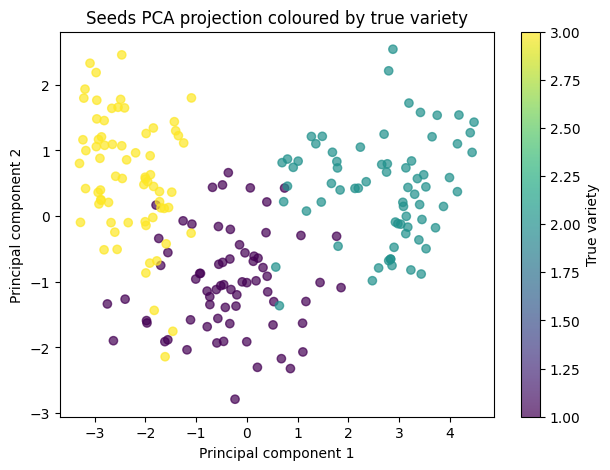

In [9]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(X2[:, 0], X2[:, 1], c=y_true, cmap="viridis", alpha=0.7)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Seeds PCA projection coloured by true variety")
cbar = plt.colorbar(sc)
cbar.set_label("True variety")
plt.show()


### What each cluster captured

Finally, see what each cluster actually represents. The cluster centres are stored in scaled units, so turn them back into the original measurements with `scaler.inverse_transform`, and read across each row to picture the typical kernel in that group.

In [10]:
centres_original = scaler.inverse_transform(km.cluster_centers_)
cluster_profiles = pd.DataFrame(centres_original, columns=feature_names,
                                index=[f"Cluster {i}" for i in range(k)])
print("Cluster centre profiles (original units):")
display(cluster_profiles.round(3))


Cluster centre profiles (original units):


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
Cluster 0,11.857,13.248,0.848,5.232,2.850,4.742,5.102
Cluster 1,18.495,16.203,0.884,6.176,3.698,3.632,6.042
Cluster 2,14.438,14.338,0.882,5.515,3.259,2.707,5.121


### Ethical considerations

I would not say that the three clusters are definitely three wheat varieties just because K-Means found them. Some kernels are placed in a cluster that mostly contains another variety, so the result is not perfect. The purity score is about **0.919**, which is good, but there are still mistakes. Also, the silhouette score prefers k = 2, so the choice of three clusters should be explained carefully. In a real situation, I would use these clusters as useful evidence, not as certain labels.


## Wrapping up

For this project, I used PCA and K-Means to see how much structure could be found without using the real variety labels. The two methods for choosing k did not give exactly the same answer. The silhouette score was best for **k = 2**, while the elbow plot suggested that **k = 3** was still a useful choice. I decided to use three clusters.

After the clustering was finished, I compared the clusters with the real varieties. The purity score was about **0.919**, so the clusters matched the real groups quite well overall. Variety 2 (Rosa) was the clearest group. Most of the confusion was between varieties 1 (Kama) and 3 (Canadian).

The first two PCA components explain about **89.0%** of the variance, so the PCA plot gives a useful picture of the data. However, it is still only a two-dimensional view, while K-Means used all seven scaled features.

### Personal reflection

I found the PCA plot and the main K-Means steps fairly easy to follow once the data had been scaled. The hardest part for me was choosing the number of clusters, because the elbow method and the silhouette score did not give exactly the same answer. I had to look at both results and explain why I chose k = 3 instead of just following one score.

I think keeping the real labels hidden until the end worked well because it made the clustering a fair test. If I had more time, I would try another clustering method and compare the results. I would also test whether changing the random seed changes the clusters very much.
